In [84]:
import random

In [85]:
# inputs
N = 10
K = 2
A = 10
B = 1
Y = [random.randint(1, 100) for _ in range(N)]
U = 0

In [13]:
def travel_cost(from_year_U, to_year_V):
    if from_year_U <= to_year_V: return A * (to_year_V - from_year_U)
    else: return B * (from_year_U - to_year_V) * (from_year_U - to_year_V)

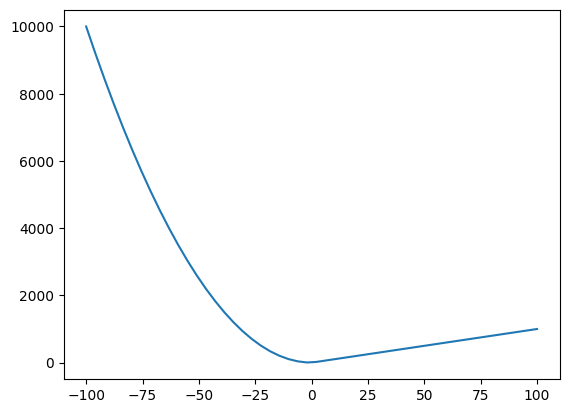

In [81]:
import numpy as np
import matplotlib.pyplot as plt

Xs = np.linspace(-100, 100)
Ys = [travel_cost(0,x) for x in Xs]

plt.plot(Xs,Ys)


1277805 (98, 98, 92, 87, 86, 78, 36, 30, 16, 5) 3248


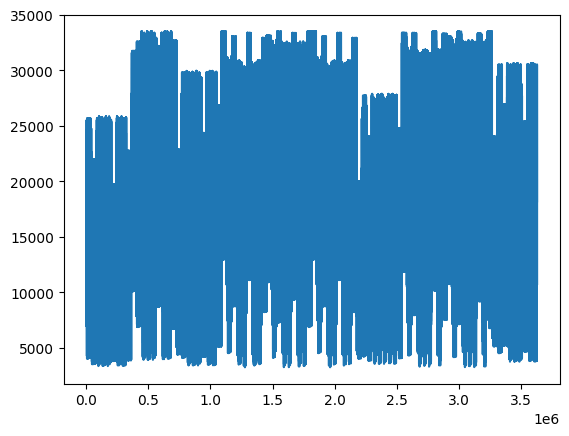

In [87]:
from itertools import permutations
instances = {
    "permutation": (),
    "cost":int,
    "cost_components": []
}
solutions = {
     "instances": []
}

for p in permutations(Y):
    costs_help = []
    costs_help.append(travel_cost(0,p[0]))
    for i in range(N-1):
         costs_help.append(travel_cost(p[i],p[i+1]))
    costs_help.append(travel_cost(p[N-1],0))


    solutions["instances"].append({
        "permutation": p,
        "cost": sum(costs_help),
        "cost_components": costs_help
    })

qqq = solutions["instances"]
costs_y = []
cost_min = float('inf')
cost_min_i = -1
for i in range(len(qqq)):
    current_cost = qqq[i]["cost"]

    if current_cost < cost_min: 
        cost_min = current_cost
        cost_min_i = i
    costs_y.append(current_cost)

print(cost_min_i, qqq[cost_min_i]["permutation"], qqq[cost_min_i]["cost"])
plt.plot(costs_y)

In [88]:
def solve_chrono_courier(N, K, A, B, Y):
    """
    Solves the Chrono-Courier's Dilemma.
    
    Parameters:
    N (int): Total number of packages.
    K (int): Maximum cargo capacity of the time machine.
    A (int): Energy multiplier for forward travel.
    B (int): Energy multiplier for backward travel.
    Y (list of int): Delivery years for each package.
    
    Returns:
    int: The minimum total energy required.
    """
    # 1. Sort the delivery years to ensure optimal contiguous grouping.
    # It's mathematically proven that optimal groups don't "cross" each other.
    Y.sort()
    
    # 2. Precompute prefix sums of the squared differences between adjacent deliveries.
    # PrefSum[i] stores the sum of (Y[m] - Y[m-1])^2 for 1 <= m <= i.
    # This allows us to calculate the internal backward "stepping stone" cost in O(1) time.
    PrefSum = [0] * N
    for i in range(1, N):
        PrefSum[i] = PrefSum[i-1] + (Y[i] - Y[i-1])**2
        
    # 3. Initialize the DP array. 
    # dp[i] represents the minimum cost to deliver the first i packages.
    dp = [float('inf')] * (N + 1)
    dp[0] = 0  # 0 cost to deliver 0 packages
    
    # 4. Populate the DP table
    for i in range(1, N + 1):
        # Try all valid trip sizes for the current group (from 1 up to max capacity K)
        for sz in range(1, min(i, K) + 1):
            
            # k is the 0-indexed starting package of the current trip group
            k = i - sz 
            # i-1 is the 0-indexed furthest package of the current trip group
            
            # Forward leg: Go directly to the furthest package in the current group
            forward_cost = A * Y[i-1]
            
            # Backward leg: Step backwards through the group to minimize quadratic penalty
            internal_steps = PrefSum[i-1] - PrefSum[k]
            return_to_zero = Y[k]**2
            backward_cost = B * (internal_steps + return_to_zero)
            
            trip_cost = forward_cost + backward_cost
            
            # State transition: Min cost to deliver 'k' packages + cost of this specific trip
            if dp[k] + trip_cost < dp[i]:
                dp[i] = dp[k] + trip_cost
                
    return int(dp[N])

# --- Example Usage ---
N = 3
K = 2
A = 10
B = 1
Y = [20, 50, 100]
print("Minimum Energy:", solve_chrono_courier(N, K, A, B, Y))
# Expected Output: 6600

Minimum Energy: 6600


In [95]:
# inputs
N = 20
K = 4
A = 10
B = 4
Y = [random.randint(1, 100) for _ in range(N)]
print("Minimum Energy:", solve_chrono_courier(N, K, A, B, Y))


Minimum Energy: 42766
